# 03: Structural metrics: Exact Match and Component F1

String-level comparison of generated vs gold query, no DB. Canonicalisation (comment-strip, alpha-rename of bindings, keyword upper-casing) lives in `harness.canonical` (shared with notebook 04); component extraction and F1 in `harness.components`.

- **Exact Match (EM)**: equality of canonical strings.
- **Component F1**: per-clause F1 (node labels, edge types, directions, WHERE/RETURN/ORDER, LIMIT, aggregations), macro-averaged. Diagnostic for *where* the model fails.

Metrics are computed for every target present and shown per target (per-model per-query tables, then a per-target aggregation by model), followed by a run-level summary; the figures keep the targets separate. An identity sanity test (gold vs itself -> EM=True, F1=1.0) runs first.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "eval"))

import pandas as pd
from harness import GOLD_DIR, METRICS_STRUCTURAL_CSV, RECORDS_DIR, load_dataset, load_records
from harness.canonical import exact_match
from harness.components import component_f1

OUT_CSV = METRICS_STRUCTURAL_CSV
from harness import plots

## Identity sanity test

Feed each gold query as its own translation; EM must be True and F1 = 1.0 for every target present in the datasets.

In [2]:
identity_rows = []
for ds_path in sorted(GOLD_DIR.glob('*.yaml')):
    for q in load_dataset(ds_path.stem):
        for target, ref in q.expected.items():
            em = exact_match(ref, ref, target)
            cf = component_f1(ref, ref, target)['overall']
            identity_rows.append((ds_path.stem, q.id, target, em, cf))
identity_df = pd.DataFrame(identity_rows, columns=['dataset','query_id','target','em','component_f1'])
n_em = int((~identity_df['em']).sum())
n_cf = int((identity_df['component_f1'] < 0.999).sum())
print(f'Identity test: {len(identity_df)} cases; EM failures: {n_em}; F1<1.0: {n_cf}')
if n_em or n_cf:
    display(identity_df[(~identity_df['em']) | (identity_df['component_f1'] < 0.999)])
    raise AssertionError('Identity sanity test failed: canonicalisation has a bug.')
print('PASS')

Identity test: 45 cases; EM failures: 0; F1<1.0: 0
PASS


## Compute on the real records

Failed translations (null `generated_query`) get zeros so the report can tell 'failed to translate' from 'translated but wrong'.

In [3]:
records = load_records(RECORDS_DIR)
keys = ['dataset','target','model','query_id','difficulty']
rows = []
for r in records:
    translated = r.get('generated_query')
    expected = r['expected_query']
    target = r['target']
    base = {k: r[k] for k in keys}
    if not translated:
        rows.append({**base, 'exact_match': False, 'component_f1_overall': 0.0,
                     'f1_node_labels': 0.0, 'f1_edge_types': 0.0, 'f1_directions': 0.0,
                     'f1_where': 0.0, 'f1_return': 0.0, 'f1_order': 0.0, 'f1_limit': 0.0,
                     'f1_aggregations': 0.0})
        continue
    em = exact_match(translated, expected, target)
    cf = component_f1(translated, expected, target)
    rows.append({**base, 'exact_match': em, 'component_f1_overall': cf['overall'],
                 'f1_node_labels': cf['node_labels'], 'f1_edge_types': cf['edge_types'],
                 'f1_directions': cf['directions'], 'f1_where': cf['where'], 'f1_return': cf['return'],
                 'f1_order': cf['order'], 'f1_limit': cf['limit'], 'f1_aggregations': cf['aggregations']})
struct_df = pd.DataFrame(rows)

## Per-target results

One section per target, one subsection per model: the model's per-query structural metrics, then a per-target aggregation by model.

In [4]:
metric_cols = ['exact_match','component_f1_overall','f1_node_labels','f1_edge_types',
               'f1_directions','f1_where','f1_return','f1_order','f1_limit','f1_aggregations']

def show_model(target, model):
    """Per-query structural metrics for one (target, model) cell."""
    sub = struct_df[(struct_df['target'] == target) & (struct_df['model'] == model)]
    if not len(sub):
        print(f'No records for {target}/{model} yet.')
        return None
    return sub[['query_id', 'difficulty'] + metric_cols].sort_values('query_id').reset_index(drop=True)

def summarize_target(target):
    """Mean structural metrics for one target, by model."""
    sub = struct_df[struct_df['target'] == target]
    if not len(sub):
        print(f'No records for {target} yet.')
        return None
    return sub.groupby('model')[metric_cols].mean()

## SQL → Cypher

### llama3.2:latest

In [5]:
show_model('cypher', 'llama3.2:latest')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
1,ldbc_q02,easy,False,0.767045,0.666667,1.0,0.000000,0.636364,0.833333,1.000000,1.0,1.000000
2,ldbc_q03,easy,False,0.708333,0.666667,1.0,0.000000,0.000000,1.000000,1.000000,1.0,1.000000
3,ldbc_q04,hard,False,0.988636,1.000000,1.0,1.000000,1.000000,0.909091,1.000000,1.0,1.000000
4,ldbc_q05,hard,False,0.617029,0.400000,1.0,0.000000,0.000000,0.869565,1.000000,1.0,0.666667
5,ldbc_q06,medium,False,0.812500,0.500000,1.0,0.000000,1.000000,1.000000,1.000000,1.0,1.000000
6,ldbc_q07,medium,False,0.827223,0.909091,1.0,0.400000,0.608696,0.700000,1.000000,1.0,1.000000
7,ldbc_q08,hard,False,0.664773,0.500000,1.0,0.000000,0.000000,0.818182,1.000000,1.0,1.000000
8,ldbc_q09,medium,False,0.810606,1.000000,1.0,1.000000,0.000000,0.818182,0.666667,1.0,1.000000
9,ldbc_q10,hard,False,0.896569,0.666667,1.0,1.000000,1.000000,0.705882,0.800000,1.0,1.000000


### qwen3-coder:30b

In [6]:
show_model('cypher', 'qwen3-coder:30b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.00,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.00,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.0
2,ldbc_q03,easy,True,1.000000,1.00,1.0,1.000000,1.000000,1.000000,1.0,1.0,1.0
3,ldbc_q04,hard,False,0.972222,1.00,1.0,1.000000,1.000000,0.777778,1.0,1.0,1.0
4,ldbc_q05,hard,False,0.722222,1.00,1.0,0.000000,0.000000,0.777778,1.0,1.0,1.0
5,ldbc_q06,medium,False,0.975000,1.00,1.0,1.000000,1.000000,0.800000,1.0,1.0,1.0
6,ldbc_q07,medium,False,0.926136,1.00,1.0,0.500000,0.909091,1.000000,1.0,1.0,1.0
7,ldbc_q08,hard,False,0.963636,1.00,1.0,1.000000,0.800000,0.909091,1.0,1.0,1.0
8,ldbc_q09,medium,False,0.802083,0.75,1.0,0.666667,0.000000,1.000000,1.0,1.0,1.0
9,ldbc_q10,hard,False,0.875000,1.00,1.0,0.000000,1.000000,1.000000,1.0,1.0,1.0


### gemma4:26b

In [7]:
show_model('cypher', 'gemma4:26b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
2,ldbc_q03,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
3,ldbc_q04,hard,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
4,ldbc_q05,hard,False,0.838636,1.0,1.0,0.00,0.800000,0.909091,1.0,1.0,1.0
5,ldbc_q06,medium,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
6,ldbc_q07,medium,False,0.926136,1.0,1.0,0.50,0.909091,1.000000,1.0,1.0,1.0
7,ldbc_q08,hard,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
8,ldbc_q09,medium,False,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
9,ldbc_q10,hard,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0


### claude-opus-4-8

In [8]:
show_model('cypher', 'claude-opus-4-8')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
2,ldbc_q03,easy,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
3,ldbc_q04,hard,False,0.988636,1.0,1.0,1.00,1.000000,0.909091,1.0,1.0,1.0
4,ldbc_q05,hard,False,0.838636,1.0,1.0,0.00,0.800000,0.909091,1.0,1.0,1.0
5,ldbc_q06,medium,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
6,ldbc_q07,medium,False,0.926136,1.0,1.0,0.50,0.909091,1.000000,1.0,1.0,1.0
7,ldbc_q08,hard,True,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
8,ldbc_q09,medium,False,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0
9,ldbc_q10,hard,False,1.000000,1.0,1.0,1.00,1.000000,1.000000,1.0,1.0,1.0


### Visualizations

SQL -> Cypher: 4 model(s), 15 query id(s)


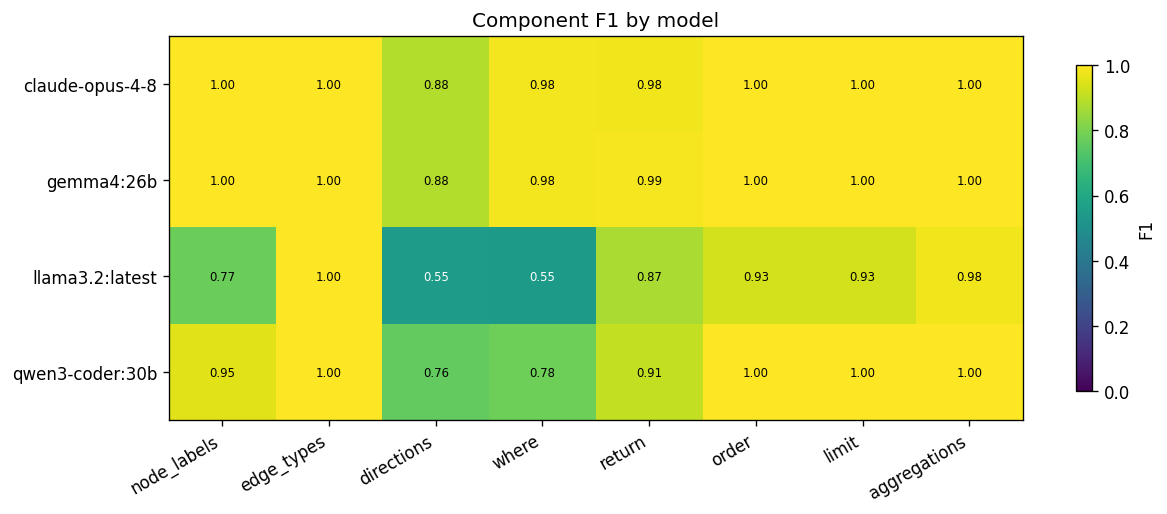

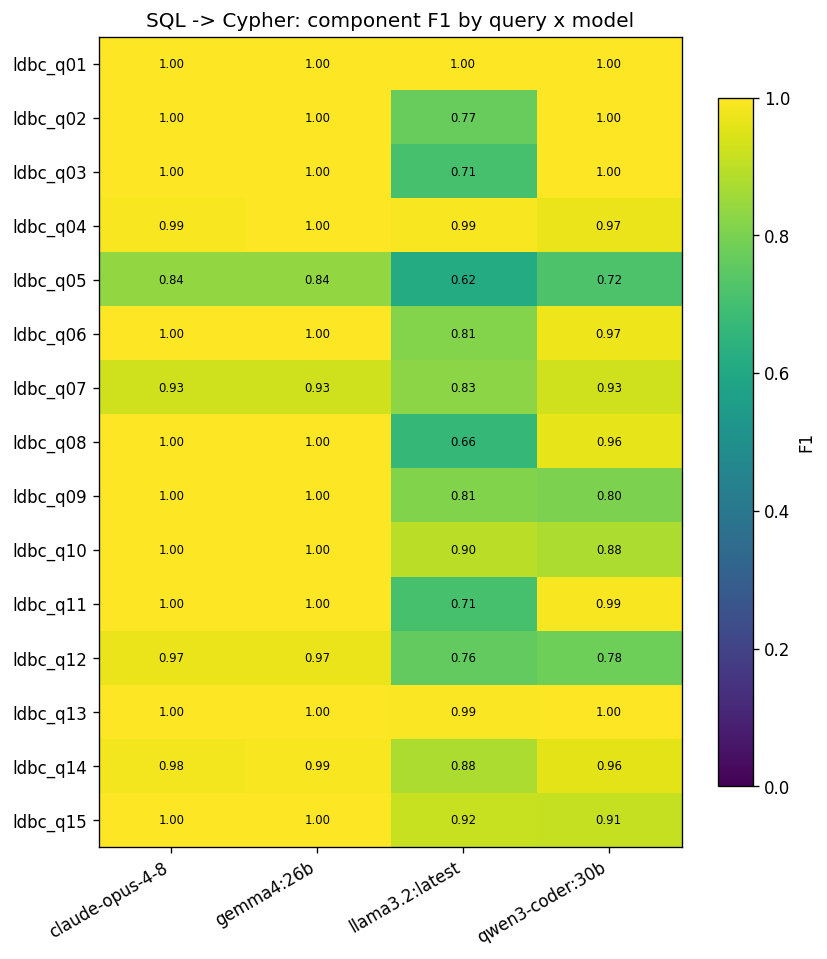

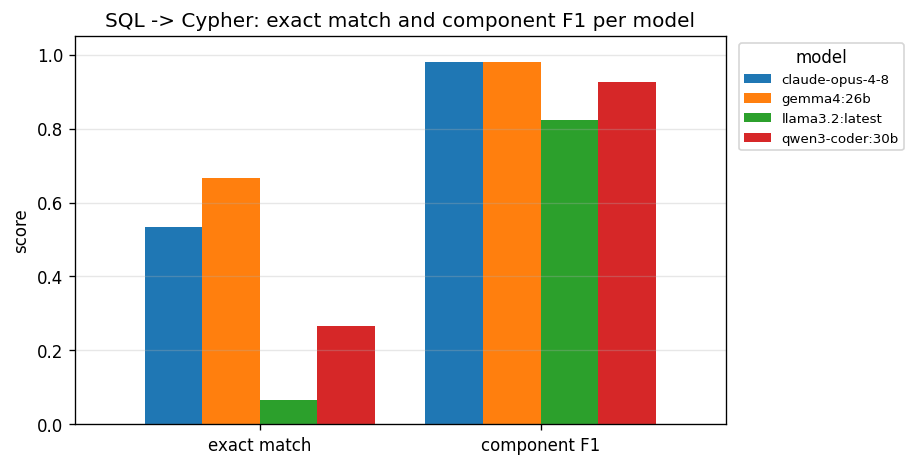

In [9]:
plots.render_target(struct_df[struct_df['target'] == 'cypher'], 'cypher', 'SQL -> Cypher', plots.FIGURE_SETS['structural'])

### Aggregation by model

In [10]:
summarize_target('cypher')

,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
model,,,,,,,,,,
claude-opus-4-8,0.533333,0.980390,1.000000,1.0,0.883333,0.980606,0.979183,1.000000,1.000000,1.000000
gemma4:26b,0.666667,0.981477,1.000000,1.0,0.883333,0.980606,0.987879,1.000000,1.000000,1.000000
llama3.2:latest,0.066667,0.823287,0.773853,1.0,0.548889,0.546496,0.874833,0.931111,0.933333,0.977778
qwen3-coder:30b,0.266667,0.925120,0.953333,1.0,0.760317,0.780606,0.906705,1.000000,1.000000,1.000000


## SQL → AQL

### llama3.2:latest

In [11]:
show_model('aql', 'llama3.2:latest')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.875000,0.0,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0
1,ldbc_q02,easy,False,0.625000,0.0,0.0,0.000000,1.000000,1.000000,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.850000,0.0,1.0,1.000000,0.800000,1.000000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.537500,0.0,0.0,1.000000,0.000000,0.800000,0.500000,1.0,1.0
4,ldbc_q05,hard,False,0.454246,0.0,0.0,0.000000,0.315789,0.818182,0.500000,1.0,1.0
5,ldbc_q06,medium,False,0.679487,0.0,0.0,0.666667,1.000000,0.769231,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.834135,0.0,1.0,1.000000,0.750000,0.923077,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.331863,0.0,0.0,0.400000,0.666667,0.588235,0.000000,0.0,1.0
8,ldbc_q09,medium,False,0.499282,0.0,0.0,0.000000,0.500000,0.827586,0.666667,1.0,1.0
9,ldbc_q10,hard,False,0.416667,0.0,0.0,1.000000,0.000000,0.833333,0.500000,0.0,1.0


### qwen3-coder:30b

In [12]:
show_model('aql', 'qwen3-coder:30b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.985000,1.000000,1.000000,1.000000,1.000000,0.880000,1.000000,1.0,1.0
1,ldbc_q02,easy,False,0.993421,1.000000,1.000000,1.000000,1.000000,0.947368,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.962500,1.000000,1.000000,1.000000,0.800000,0.900000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.725379,0.666667,1.000000,1.000000,0.000000,0.636364,0.500000,1.0,1.0
4,ldbc_q05,hard,False,0.618659,0.666667,1.000000,0.000000,0.000000,0.782609,0.500000,1.0,1.0
5,ldbc_q06,medium,False,0.980769,1.000000,1.000000,1.000000,1.000000,0.846154,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.890476,0.666667,0.800000,0.800000,1.000000,0.857143,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.895008,0.666667,0.800000,0.888889,0.947368,0.857143,1.000000,1.0,1.0
8,ldbc_q09,medium,False,0.676365,0.000000,0.666667,0.666667,0.500000,0.827586,0.750000,1.0,1.0
9,ldbc_q10,hard,False,0.879762,0.666667,1.000000,1.000000,1.000000,0.800000,0.571429,1.0,1.0


### gemma4:26b

In [13]:
show_model('aql', 'gemma4:26b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,True,1.000000,1.000000,1.0,1.0,1.000,1.000000,1.000000,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.000000,1.0,1.0,1.000,1.000000,1.000000,1.0,1.0
2,ldbc_q03,easy,True,1.000000,1.000000,1.0,1.0,1.000,1.000000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.720833,0.666667,1.0,1.0,1.000,0.600000,0.500000,1.0,0.0
4,ldbc_q05,hard,False,0.883333,0.666667,1.0,1.0,0.400,1.000000,1.000000,1.0,1.0
5,ldbc_q06,medium,False,0.990385,1.000000,1.0,1.0,1.000,0.923077,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.958333,0.666667,1.0,1.0,1.000,1.000000,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.793155,0.666667,1.0,1.0,0.750,0.928571,1.000000,1.0,0.0
8,ldbc_q09,medium,False,0.712823,0.000000,1.0,0.5,0.625,0.827586,0.750000,1.0,1.0
9,ldbc_q10,hard,False,0.873106,0.666667,1.0,1.0,1.000,0.818182,0.500000,1.0,1.0


### claude-opus-4-8

In [14]:
show_model('aql', 'claude-opus-4-8')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.985000,1.000000,1.0,1.000000,1.000000,0.880000,1.000000,1.0,1.0
1,ldbc_q02,easy,True,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.975000,1.000000,1.0,1.000000,0.800000,1.000000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.879762,0.666667,1.0,1.000000,1.000000,0.800000,0.571429,1.0,1.0
4,ldbc_q05,hard,False,0.780118,0.666667,1.0,0.666667,0.625000,0.782609,0.500000,1.0,1.0
5,ldbc_q06,medium,False,0.990385,1.000000,1.0,1.000000,1.000000,0.923077,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.949405,0.666667,1.0,1.000000,1.000000,0.928571,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.949405,0.666667,1.0,1.000000,1.000000,0.928571,1.000000,1.0,1.0
8,ldbc_q09,medium,False,0.712823,0.000000,1.0,0.500000,0.625000,0.827586,0.750000,1.0,1.0
9,ldbc_q10,hard,False,0.879762,0.666667,1.0,1.000000,1.000000,0.800000,0.571429,1.0,1.0


### Visualizations

SQL -> AQL: 4 model(s), 15 query id(s)


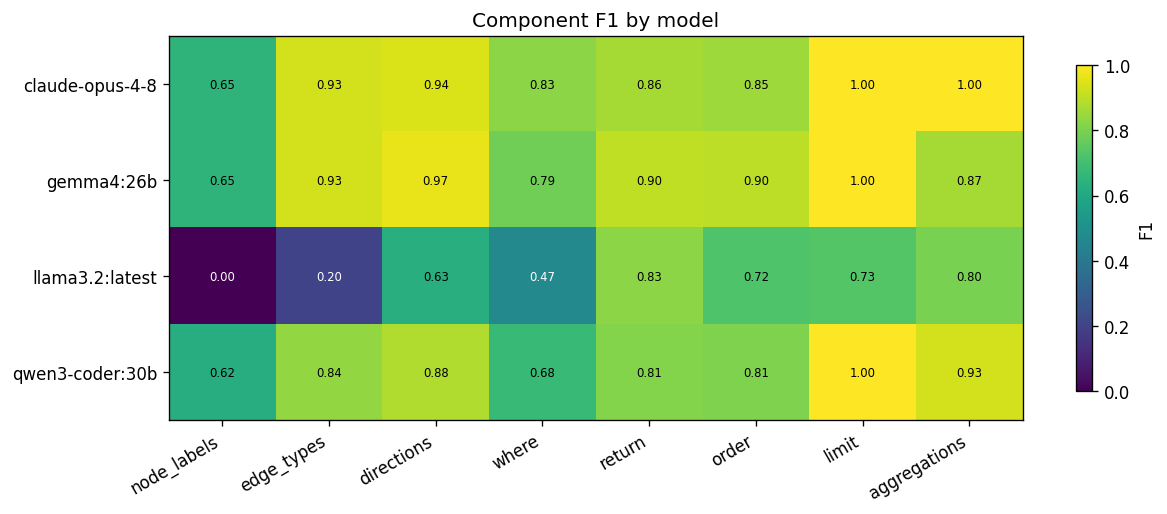

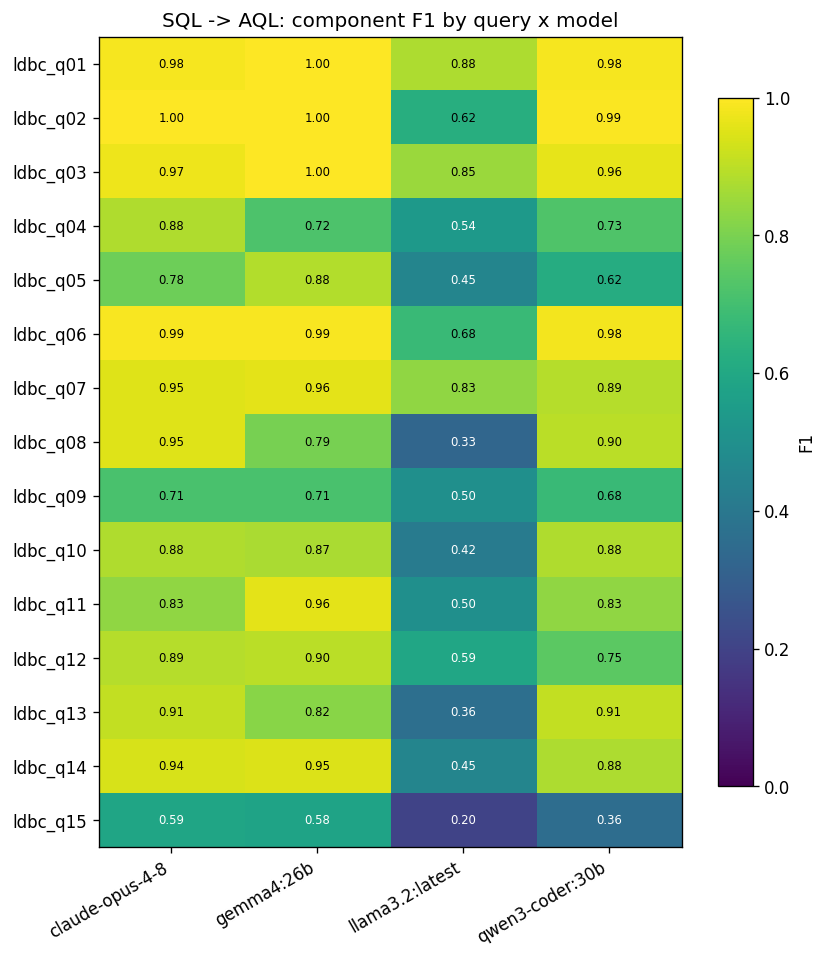

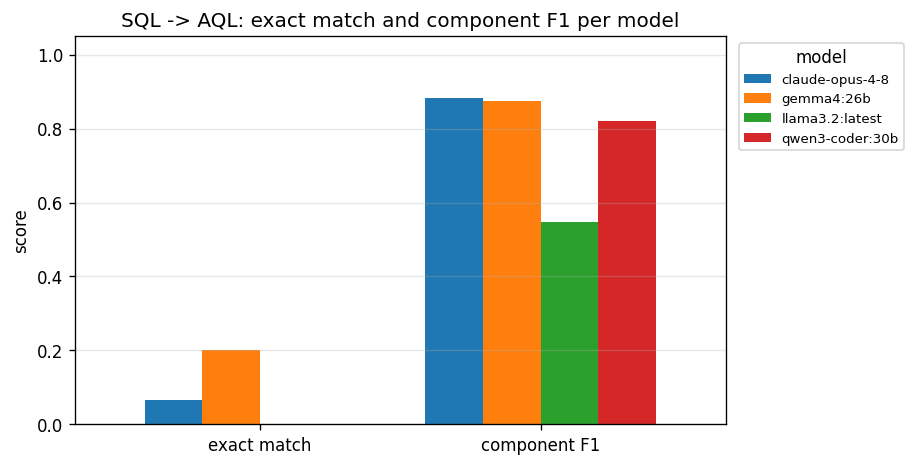

In [15]:
plots.render_target(struct_df[struct_df['target'] == 'aql'], 'aql', 'SQL -> AQL', plots.FIGURE_SETS['structural'])

### Aggregation by model

In [16]:
summarize_target('aql')

,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
model,,,,,,,,,,
claude-opus-4-8,0.066667,0.883675,0.648889,0.933333,0.944444,0.825556,0.863999,0.853175,1.000000,1.000000
gemma4:26b,0.200000,0.875839,0.648889,0.933333,0.966667,0.785000,0.904870,0.901282,1.000000,0.866667
llama3.2:latest,0.000000,0.547494,0.000000,0.200000,0.626667,0.470138,0.825368,0.724444,0.733333,0.800000
qwen3-coder:30b,0.000000,0.821752,0.622222,0.837778,0.880847,0.678713,0.814929,0.806190,1.000000,0.933333


## SQL → Gremlin

### llama3.2:latest

In [17]:
show_model('gremlin', 'llama3.2:latest')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.800000,0.000000,1.000000,1.000000,0.400000,1.000000,1.000000,1.0,1.000000
1,ldbc_q02,easy,False,0.821429,0.666667,1.000000,1.000000,0.571429,0.333333,1.000000,1.0,1.000000
2,ldbc_q03,easy,False,0.843750,0.000000,1.000000,1.000000,0.750000,1.000000,1.000000,1.0,1.000000
3,ldbc_q04,hard,False,0.669981,0.000000,1.000000,0.500000,0.500000,0.818182,0.875000,1.0,0.666667
4,ldbc_q05,hard,False,0.578010,0.500000,0.500000,0.400000,0.000000,0.608696,0.615385,1.0,1.000000
5,ldbc_q06,medium,False,0.728291,0.000000,1.000000,0.666667,0.571429,0.588235,1.000000,1.0,1.000000
6,ldbc_q07,medium,False,0.541667,0.000000,0.000000,0.666667,0.583333,0.083333,1.000000,1.0,1.000000
7,ldbc_q08,hard,False,0.636497,0.000000,0.800000,0.500000,0.315789,0.476190,1.000000,1.0,1.000000
8,ldbc_q09,medium,False,0.608967,0.000000,0.800000,0.800000,0.750000,0.521739,0.000000,1.0,1.000000
9,ldbc_q10,hard,False,0.734848,1.000000,1.000000,0.666667,1.000000,0.666667,0.545455,1.0,0.000000


### qwen3-coder:30b

In [18]:
show_model('gremlin', 'qwen3-coder:30b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.975000,1.000000,1.000000,1.000000,1.000000,0.800000,1.000000,1.0,1.000000
1,ldbc_q02,easy,False,0.937500,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000,1.0,1.000000
2,ldbc_q03,easy,False,0.957143,1.000000,1.000000,1.000000,0.857143,0.800000,1.000000,1.0,1.000000
3,ldbc_q04,hard,False,0.748868,1.000000,1.000000,0.666667,0.000000,0.782609,0.875000,1.0,0.666667
4,ldbc_q05,hard,False,0.706374,1.000000,1.000000,0.000000,1.000000,0.620690,0.363636,1.0,0.666667
5,ldbc_q06,medium,False,0.940789,1.000000,1.000000,1.000000,1.000000,0.526316,1.000000,1.0,1.000000
6,ldbc_q07,medium,False,0.945000,1.000000,1.000000,1.000000,1.000000,0.560000,1.000000,1.0,1.000000
7,ldbc_q08,hard,False,0.835602,1.000000,1.000000,0.750000,0.814815,0.120000,1.000000,1.0,1.000000
8,ldbc_q09,medium,False,0.744449,0.666667,0.666667,0.666667,0.571429,0.838710,0.545455,1.0,1.000000
9,ldbc_q10,hard,False,0.911458,1.000000,1.000000,0.500000,1.000000,0.916667,0.875000,1.0,1.000000


### gemma4:26b

In [19]:
show_model('gremlin', 'gemma4:26b')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.957143,1.000000,1.0,1.000000,0.857143,0.800000,1.000000,1.0,1.0
1,ldbc_q02,easy,False,0.937500,1.000000,1.0,1.000000,1.000000,0.500000,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.982143,1.000000,1.0,1.000000,0.857143,1.000000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.943182,1.000000,1.0,1.000000,1.000000,1.000000,0.545455,1.0,1.0
4,ldbc_q05,hard,False,0.800476,1.000000,1.0,0.666667,0.000000,0.880000,0.857143,1.0,1.0
5,ldbc_q06,medium,False,0.955357,1.000000,1.0,1.000000,0.857143,0.785714,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.979167,1.000000,1.0,1.000000,1.000000,0.833333,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.975806,1.000000,1.0,1.000000,0.903226,0.903226,1.000000,1.0,1.0
8,ldbc_q09,medium,False,0.751962,0.666667,1.0,0.500000,0.428571,0.875000,0.545455,1.0,1.0
9,ldbc_q10,hard,False,0.943182,1.000000,1.0,1.000000,1.000000,1.000000,0.545455,1.0,1.0


### claude-opus-4-8

In [20]:
show_model('gremlin', 'claude-opus-4-8')

,query_id,difficulty,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
0,ldbc_q01,easy,False,0.975000,1.0,1.0,1.000000,1.000000,0.800000,1.000000,1.0,1.0
1,ldbc_q02,easy,False,0.933824,1.0,1.0,1.000000,1.000000,0.470588,1.000000,1.0,1.0
2,ldbc_q03,easy,False,0.957143,1.0,1.0,1.000000,0.857143,0.800000,1.000000,1.0,1.0
3,ldbc_q04,hard,False,0.833333,1.0,1.0,0.666667,0.000000,1.000000,1.000000,1.0,1.0
4,ldbc_q05,hard,False,0.922500,0.5,1.0,1.000000,1.000000,0.880000,1.000000,1.0,1.0
5,ldbc_q06,medium,False,0.940789,1.0,1.0,1.000000,1.000000,0.526316,1.000000,1.0,1.0
6,ldbc_q07,medium,False,0.982143,1.0,1.0,1.000000,1.000000,0.857143,1.000000,1.0,1.0
7,ldbc_q08,hard,False,0.950513,1.0,1.0,1.000000,0.967742,0.636364,1.000000,1.0,1.0
8,ldbc_q09,medium,False,0.786932,1.0,1.0,0.500000,0.500000,0.750000,0.545455,1.0,1.0
9,ldbc_q10,hard,True,1.000000,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.0,1.0


### Visualizations

SQL -> Gremlin: 4 model(s), 15 query id(s)


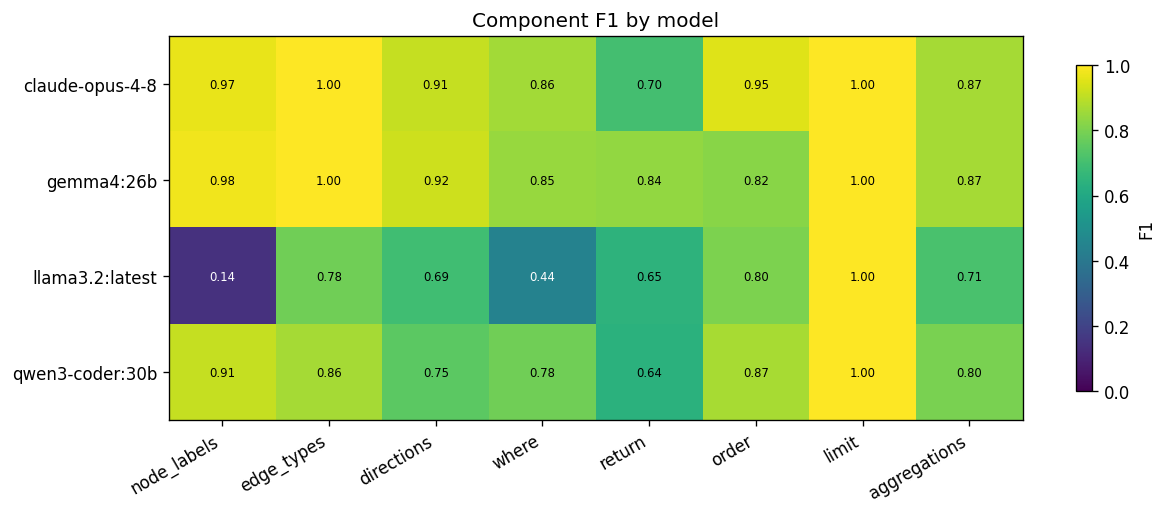

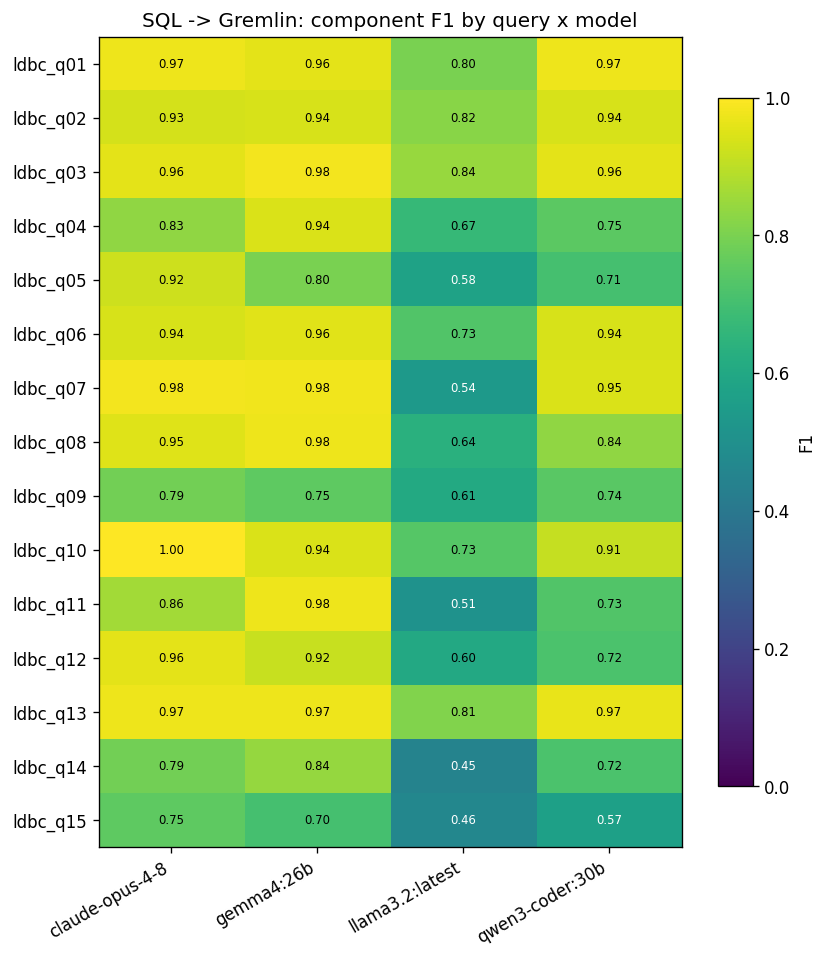

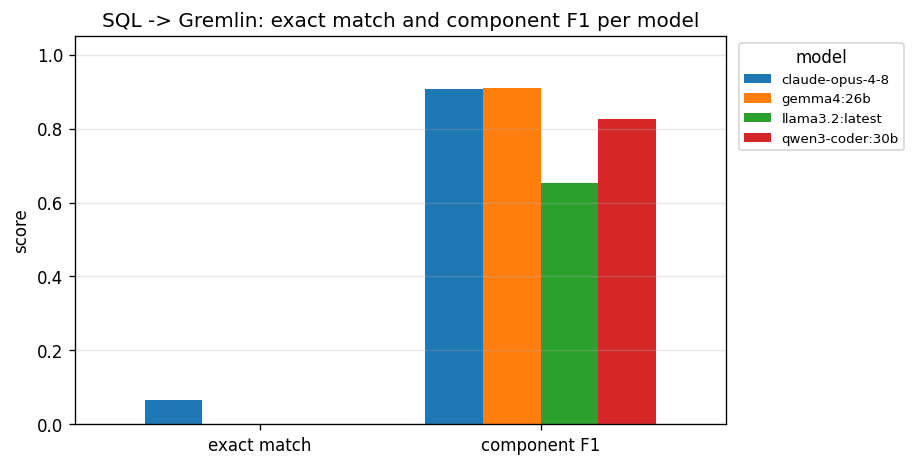

In [21]:
plots.render_target(struct_df[struct_df['target'] == 'gremlin'], 'gremlin', 'SQL -> Gremlin', plots.FIGURE_SETS['structural'])

### Aggregation by model

In [22]:
summarize_target('gremlin')

,exact_match,component_f1_overall,f1_node_labels,f1_edge_types,f1_directions,f1_where,f1_return,f1_order,f1_limit,f1_aggregations
model,,,,,,,,,,
claude-opus-4-8,0.066667,0.907426,0.966667,1.000000,0.911111,0.862929,0.701947,0.950089,1.0,0.866667
gemma4:26b,0.000000,0.909241,0.977778,1.000000,0.922222,0.847182,0.836699,0.823377,1.0,0.866667
llama3.2:latest,0.000000,0.653274,0.144444,0.784444,0.693333,0.444568,0.645898,0.802389,1.0,0.711111
qwen3-coder:30b,0.000000,0.826638,0.911111,0.864444,0.746825,0.782526,0.640019,0.868182,1.0,0.800000


## Run-level summary

The whole matrix at a glance: the per-cell (dataset x target x model) means and the difficulty stratification. No cross-target average is computed; targets are never mixed.

In [23]:
print('By dataset x target x model:')
display(struct_df.groupby(['dataset','target','model'])[metric_cols].mean())
print('By target x difficulty:')
_bd = struct_df.copy()
_bd['difficulty'] = pd.Categorical(_bd['difficulty'], ['easy','medium','hard'], ordered=True)
display(_bd.groupby(['target','difficulty'], observed=True)[metric_cols].mean())

By dataset x target x model:


exact_match  component_f1_overall  \
dataset target  model                                                
ldbc    aql     claude-opus-4-8     0.066667              0.883675   
                gemma4:26b          0.200000              0.875839   
                llama3.2:latest     0.000000              0.547494   
                qwen3-coder:30b     0.000000              0.821752   
        cypher  claude-opus-4-8     0.533333              0.980390   
                gemma4:26b          0.666667              0.981477   
                llama3.2:latest     0.066667              0.823287   
                qwen3-coder:30b     0.266667              0.925120   
        gremlin claude-opus-4-8     0.066667              0.907426   
                gemma4:26b          0.000000              0.909241   
                llama3.2:latest     0.000000              0.653274   
                qwen3-coder:30b     0.000000              0.826638   

                                 f1_node_labels  f1_edge_types  f1_directions  \
dataset target  model                                                           
ldbc    aql     claude-opus-4-8        0.648889       0.933333       0.944444   
                gemma4:26b             0.648889       0.933333       0.966667   
                llama3.2:latest        0.000000       0.200000       0.626667   
                qwen3-coder:30b        0.622222       0.837778       0.880847   
        cypher  claude-opus-4-8        1.000000       1.000000       0.883333   
                gemma4:26b             1.000000       1.000000       0.883333   
                llama3.2:latest        0.773853       1.000000       0.548889   
                qwen3-coder:30b        0.953333       1.000000       0.760317   
        gremlin claude-opus-4-8        0.966667       1.000000       0.911111   
                gemma4:26b             0.977778       1.000000       0.922222   
                llama3.2:latest        0.144444       0.784444       0.693333   
                qwen3-coder:30b        0.911111       0.864444       0.746825   

                                 f1_where  f1_return  f1_order  f1_limit  \
dataset target  model                                                      
ldbc    aql     claude-opus-4-8  0.825556   0.863999  0.853175  1.000000   
                gemma4:26b       0.785000   0.904870  0.901282  1.000000   
                llama3.2:latest  0.470138   0.825368  0.724444  0.733333   
                qwen3-coder:30b  0.678713   0.814929  0.806190  1.000000   
        cypher  claude-opus-4-8  0.980606   0.979183  1.000000  1.000000   
                gemma4:26b       0.980606   0.987879  1.000000  1.000000   
                llama3.2:latest  0.546496   0.874833  0.931111  0.933333   
                qwen3-coder:30b  0.780606   0.906705  1.000000  1.000000   
        gremlin claude-opus-4-8  0.862929   0.701947  0.950089  1.000000   
                gemma4:26b       0.847182   0.836699  0.823377  1.000000   
                llama3.2:latest  0.444568   0.645898  0.802389  1.000000   
                qwen3-coder:30b  0.782526   0.640019  0.868182  1.000000   

                                 f1_aggregations  
dataset target  model                             
ldbc    aql     claude-opus-4-8         1.000000  
                gemma4:26b              0.866667  
                llama3.2:latest         0.800000  
                qwen3-coder:30b         0.933333  
        cypher  claude-opus-4-8         1.000000  
                gemma4:26b              1.000000  
                llama3.2:latest         0.977778  
                qwen3-coder:30b         1.000000  
        gremlin claude-opus-4-8         0.866667  
                gemma4:26b              0.866667  
                llama3.2:latest         0.711111  
                qwen3-coder:30b         0.800000

By target x difficulty:


exact_match  component_f1_overall  f1_node_labels  \
target  difficulty                                                      
aql     easy           0.333333              0.937577        0.750000   
        medium         0.000000              0.818152        0.437500   
        hard           0.000000              0.705938        0.400000   
cypher  easy           0.833333              0.956282        0.944444   
        medium         0.125000              0.925783        0.905032   
        hard           0.343750              0.917694        0.940436   
gremlin easy           0.000000              0.923131        0.805556   
        medium         0.000000              0.793710        0.708333   
        hard           0.031250              0.802242        0.750000   

                    f1_edge_types  f1_directions  f1_where  f1_return  \
target  difficulty                                                      
aql     easy             0.916667       0.916667  0.950000   0.967281   
        medium           0.747917       0.820833  0.812500   0.856674   
        hard             0.643750       0.848313  0.530972   0.806980   
cypher  easy             1.000000       0.833333  0.886364   0.986111   
        medium           1.000000       0.764583  0.833498   0.923982   
        hard             1.000000       0.747024  0.792262   0.925374   
gremlin easy             1.000000       1.000000  0.845833   0.733660   
        medium           0.852083       0.825000  0.766369   0.595625   
        hard             0.909375       0.746949  0.676443   0.751078   

                    f1_order  f1_limit  f1_aggregations  
target  difficulty                                       
aql     easy        1.000000   1.00000         1.000000  
        medium      0.932292   1.00000         0.937500  
        hard        0.698741   0.87500         0.843750  
cypher  easy        1.000000   1.00000         1.000000  
        medium      0.979167   1.00000         1.000000  
        hard        0.978125   0.96875         0.989583  
gremlin easy        1.000000   1.00000         1.000000  
        medium      0.852273   1.00000         0.750000  
        hard        0.813256   1.00000         0.770833

## Save per-record CSV

In [24]:
struct_df.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(struct_df)} rows to {OUT_CSV}')

Wrote 180 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/eval/outputs/metrics/metrics_structural.csv
